__Многопоточность python__

Поток — это наименьшая единица выполнения в процессе. Потоки разделяют общее адресное пространство, что позволяет им работать с одними и теми же данными.

GIL — это механизм в CPython, который позволяет выполняться только одному потоку за раз (даже на многоядерных CPU).

Python предоставляет модуль threading для работы с потоками.

Многопоточность (multithreading) подходит для _IO-bound задач_, использует ОС, страдает от GIL

Потоки позволяют ускорить выполнение задач 

Любая программа это минимум один процесс и один поток 

Полезно использовать daemon=True, очереди, pool executor, НО в любом случае все зависит от программиста!

Пример создания потока:

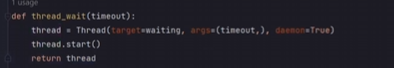

target - функция, которую в потоке мы собираемися выполнять, в args закидываем аргументы, daemon = True означает, что поток является демоном -> если главный поток завершился -> python сразу уничтожает все потоки демоны

daemon = True рекомендуется использовать для:
1) Фоновых задач (сбор статистики, пинг сервера)
2) Служебные потоки

daemon = True рекомендуется не использовать для:
1) Корректного завершения работы (закрыть файл, сохранить данные)
2) Обработки данных

Поток после создания нужно стартовать и дожидаться их выполнения:

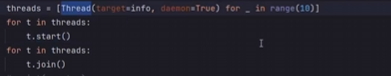

Главный поток всегда называется MainThread

Создание потока ОС -> оч дорогая операция, она не мгновенная и если наделать оч много потоков - мы можем только усугубить ситуацию

В python сложнее получить проблему race condition из-за GIL 

_Race Condition_ — это ошибка в многопоточной или многопроцессорной системе, когда результат работы программы зависит от порядка выполнения потоков. Если несколько потоков одновременно обращаются к общим данным и хотя бы один из них изменяет их, может возникнуть непредсказуемое поведение.

Для разрешения race condition используется блокировка (lock)



Мы в начале функции берем блокировку -> это означает, что кроме потока, который уже вошел в эту функцию никто туда не пройдет

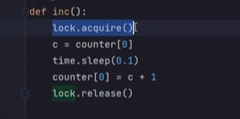

Некоторые проблемы:

1) Взаимоблокировка
2) Deadlock (обычно из-за if'ов и других условий по которым мы освободим блокировку)

Еще один из вариантов решения проблем -> создание очереди

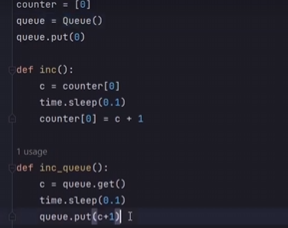

Она решает вопрос race condition без блокировок

Плюсы:

1) Просто (сравнительно)
2) Быстро
3) Не умирает из-за одного

Минусы:

1) Потребление ресурсов
2) Неуправляемость
3) Проблемы потоков (страдание от GIL, race condition)